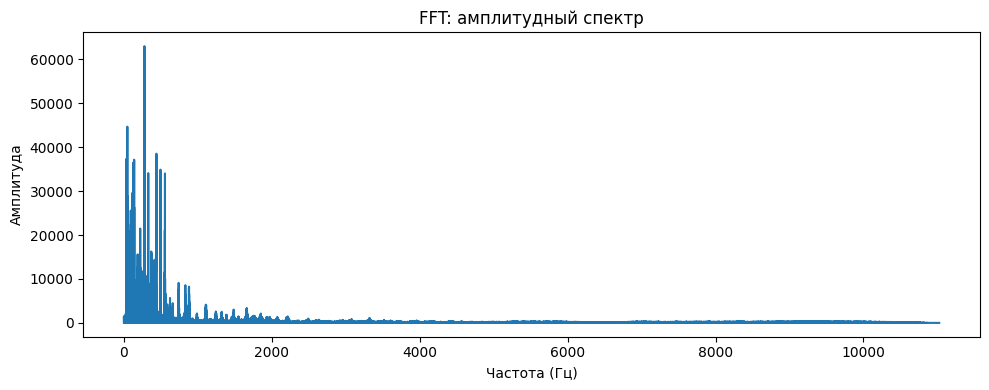

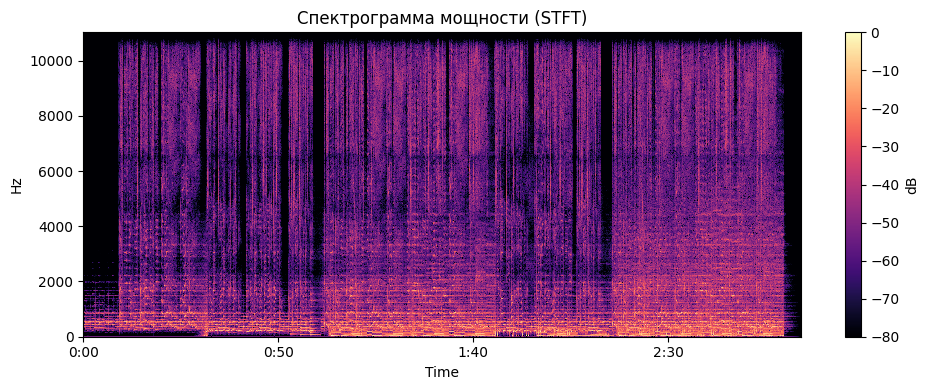

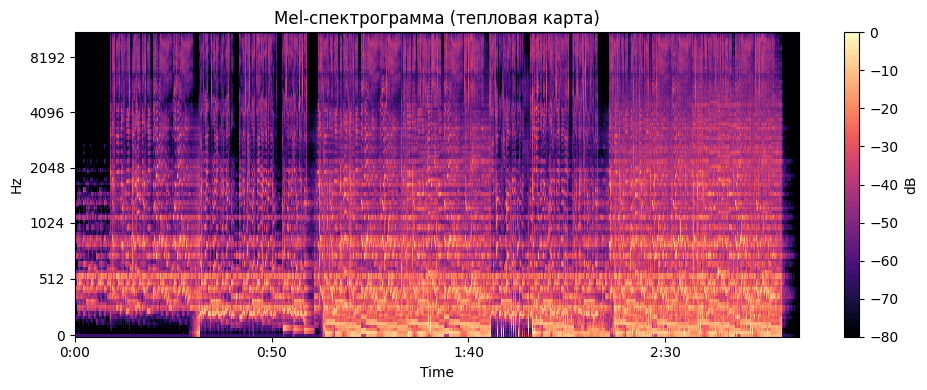

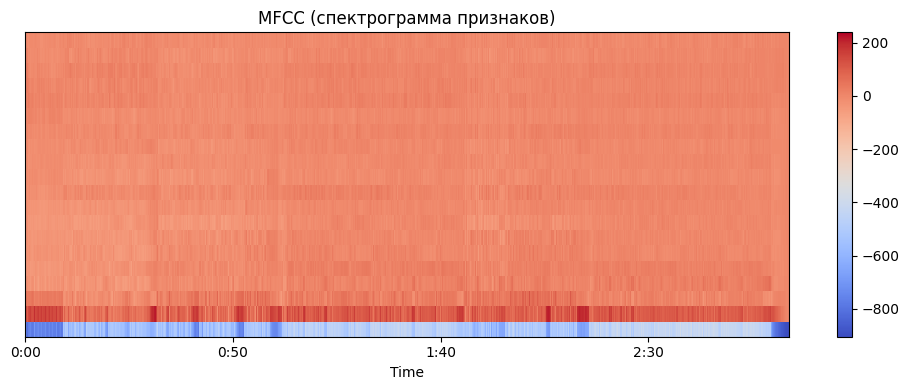

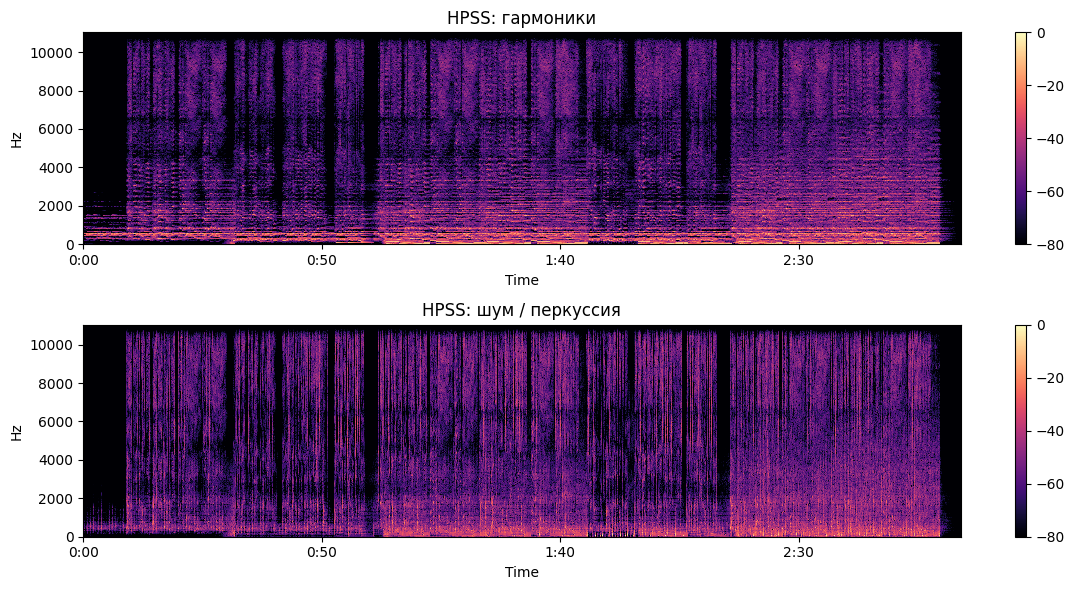

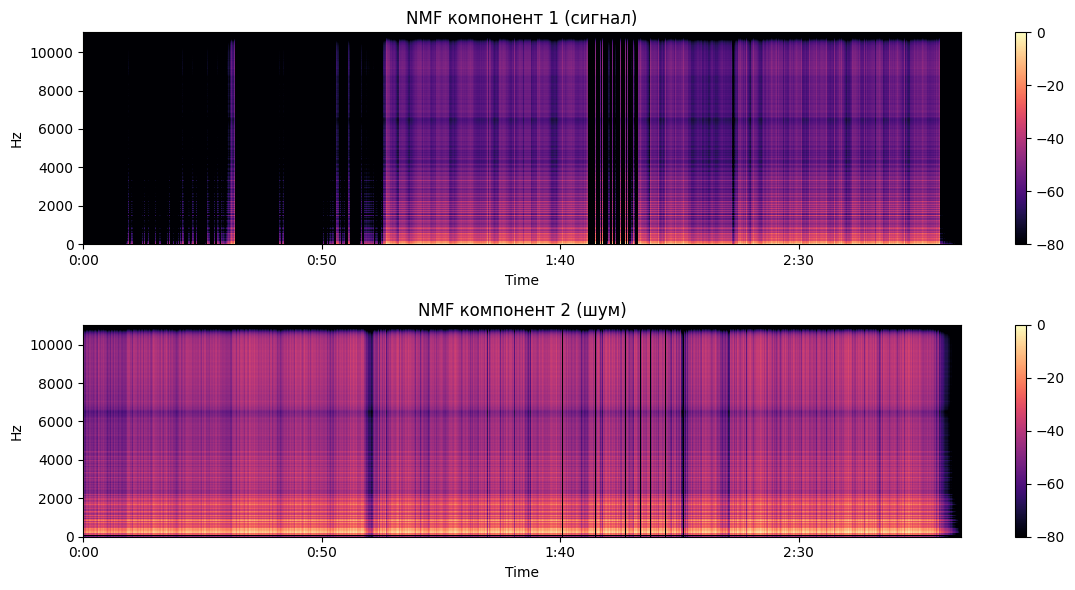

In [14]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy import stats

# ================== ПАРАМЕТРЫ ==================
SR = 22050
N_FFT = 2048
HOP = 512
N_MFCC = 20

FILE = "data/1.mp3"  # <-- замени на свой файл

# ================== ЗАГРУЗКА ==================
y, sr = librosa.load(FILE, sr=SR, mono=True)

# ================== 1. FFT ==================
fft = np.fft.rfft(y)
freqs = np.fft.rfftfreq(len(y), 1 / sr)
fft_amp = np.abs(fft)

plt.figure(figsize=(10, 4))
plt.plot(freqs, fft_amp)
plt.title("FFT: амплитудный спектр")
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.tight_layout()
plt.show()

# ================== 2. STFT ==================
S = librosa.stft(y, n_fft=N_FFT, hop_length=HOP)

# амплитуда и мощность
S_amp = np.abs(S)
S_power = S_amp ** 2

# ================== 3. СПЕКТРОГРАММА МОЩНОСТИ ==================
S_power_db = librosa.power_to_db(S_power, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    S_power_db,
    sr=sr,
    hop_length=HOP,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(label="dB")
plt.title("Спектрограмма мощности (STFT)")
plt.tight_layout()
plt.show()

# ================== 4. MEL-СПЕКТРОГРАММА ==================
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=N_FFT,
    hop_length=HOP,
    n_mels=128,
    power=2.0
)

mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=HOP,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(label="dB")
plt.title("Mel-спектрограмма (тепловая карта)")
plt.tight_layout()
plt.show()

# ================== 5. MFCC ==================
mfcc = librosa.feature.mfcc(S=mel_db, n_mfcc=N_MFCC)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, x_axis="time")
plt.colorbar()
plt.title("MFCC (спектрограмма признаков)")
plt.tight_layout()
plt.show()

# ================== 6. HPSS (гармоника / шум) ==================
H, P = librosa.decompose.hpss(S_amp)

H_db = librosa.amplitude_to_db(H, ref=np.max)
P_db = librosa.amplitude_to_db(P, ref=np.max)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
librosa.display.specshow(H_db, sr=sr, hop_length=HOP, x_axis="time", y_axis="hz")
plt.title("HPSS: гармоники")
plt.colorbar()

plt.subplot(2, 1, 2)
librosa.display.specshow(P_db, sr=sr, hop_length=HOP, x_axis="time", y_axis="hz")
plt.title("HPSS: шум / перкуссия")
plt.colorbar()

plt.tight_layout()
plt.show()

# ================== 7. NMF (ИСПРАВЛЕНО) ==================
# ВАЖНО: используем ТОЛЬКО амплитуду STFT (вещественная и >=0)

W, H_nmf = librosa.decompose.decompose(
    S_amp,
    n_components=2,
    sort=True
)

# компоненты
nmf_1 = np.outer(W[:, 0], H_nmf[0])
nmf_2 = np.outer(W[:, 1], H_nmf[1])

nmf_1_db = librosa.amplitude_to_db(nmf_1, ref=np.max)
nmf_2_db = librosa.amplitude_to_db(nmf_2, ref=np.max)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
librosa.display.specshow(nmf_1_db, sr=sr, hop_length=HOP, x_axis="time", y_axis="hz")
plt.title("NMF компонент 1 (сигнал)")
plt.colorbar()

plt.subplot(2, 1, 2)
librosa.display.specshow(nmf_2_db, sr=sr, hop_length=HOP, x_axis="time", y_axis="hz")
plt.title("NMF компонент 2 (шум)")
plt.colorbar()

plt.tight_layout()
plt.show()


In [12]:
import pandas as pd
import librosa

# Спектральные показатели
spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr).mean()
spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr).mean()
spectral_flatness = librosa.feature.spectral_flatness(y=y).mean()

# Амплитуда и RMS
max_amplitude = np.max(np.abs(y))
mean_amplitude = np.mean(np.abs(y))
rms = np.sqrt(np.mean(y**2))

# Энергия
total_power = np.sum(S_power)
mean_power = np.mean(S_power)
max_power = np.max(S_power)

# MFCC
mfcc_mean = mfcc.mean(axis=1)
mfcc_std = mfcc.std(axis=1)

# HPSS
H_power = np.sum(H**2)
P_power = np.sum(P**2)

# NMF
nmf1_power = np.sum(nmf_1**2)
nmf2_power = np.sum(nmf_2**2)

# Формируем DataFrame
data = {
    "Показатель": [
        "max_amplitude", "mean_amplitude", "RMS",
        "spectral_centroid", "spectral_bandwidth", "spectral_rolloff", "spectral_flatness",
        "total_power", "mean_power", "max_power",
        "H_power (гармоники)", "P_power (шум/перкуссия)",
        "NMF1_power", "NMF2_power"
    ],
    "Значение": [
        max_amplitude, mean_amplitude, rms,
        spectral_centroid, spectral_bandwidth, spectral_rolloff, spectral_flatness,
        total_power, mean_power, max_power,
        H_power, P_power,
        nmf1_power, nmf2_power
    ]
}

df = pd.DataFrame(data)
print(df)


                 Показатель      Значение
0             max_amplitude  9.958996e-01
1            mean_amplitude  1.894574e-01
2                       RMS  2.534183e-01
3         spectral_centroid  2.198965e+03
4        spectral_bandwidth  2.601111e+03
5          spectral_rolloff  5.388715e+03
6         spectral_flatness  1.016043e-02
7               total_power  4.000952e+08
8                mean_power  4.927250e+01
9                 max_power  1.059174e+05
10      H_power (гармоники)  2.892928e+08
11  P_power (шум/перкуссия)  4.715458e+07
12               NMF1_power  1.111426e+08
13               NMF2_power  7.505283e+07


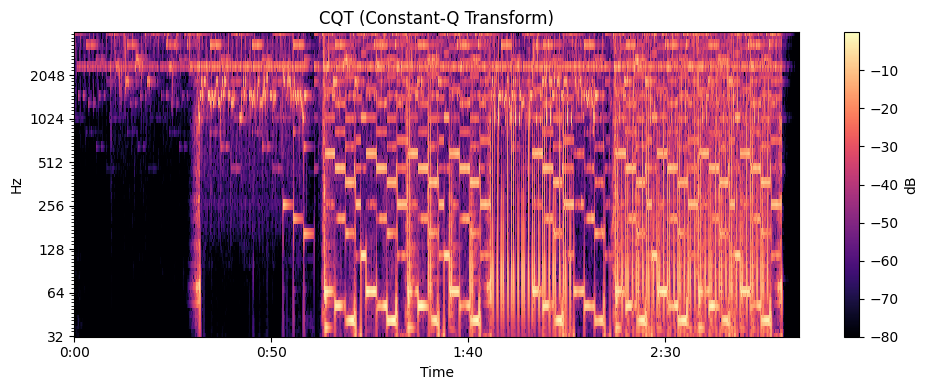

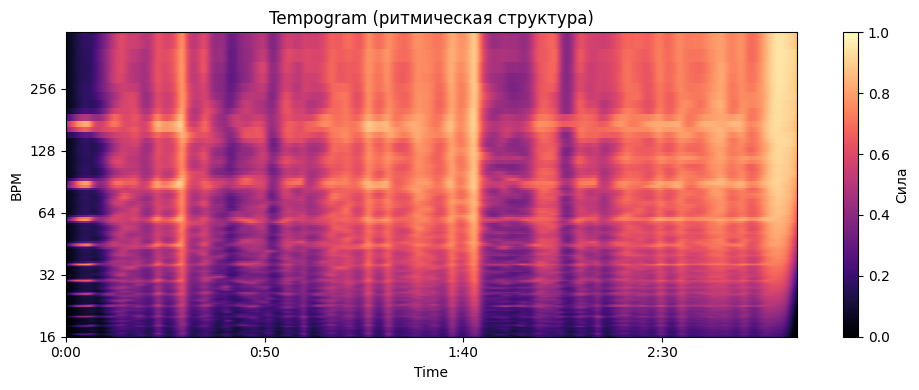

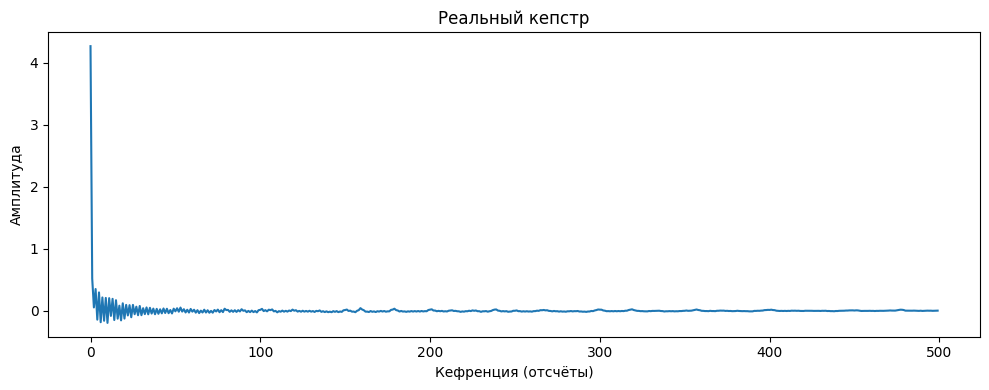

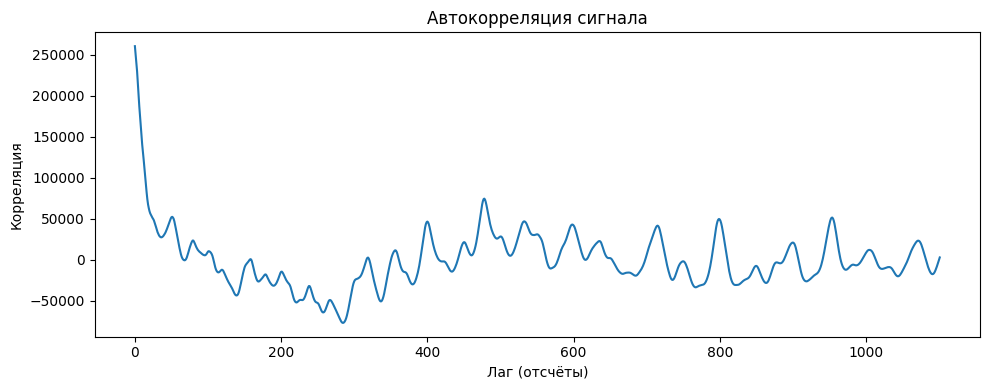

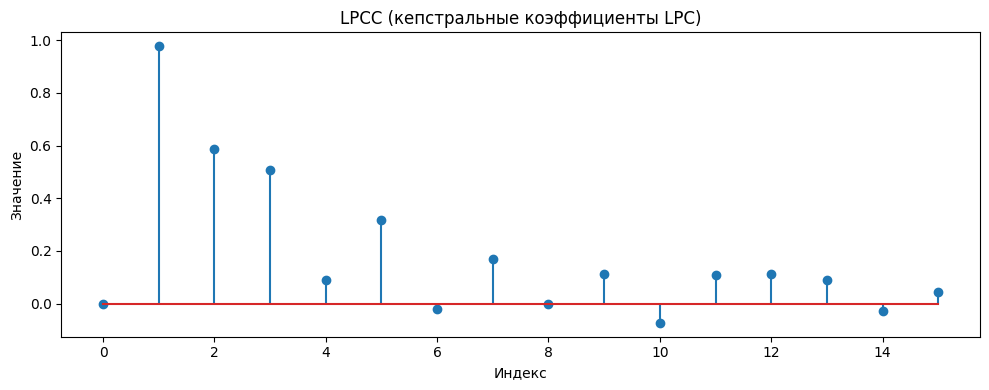

In [12]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import correlate

# ================== ПАРАМЕТРЫ ==================
SR = 22050
HOP = 512
FILE = "data/1.mp3"

# ================== ЗАГРУЗКА ==================
y, sr = librosa.load(FILE, sr=SR, mono=True)

# ============================================================
# 1. CQT — Constant-Q Transform
# ============================================================
cqt = librosa.cqt(y, sr=sr, hop_length=HOP, bins_per_octave=24)
cqt_db = librosa.amplitude_to_db(np.abs(cqt), ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    cqt_db,
    sr=sr,
    hop_length=HOP,
    x_axis="time",
    y_axis="cqt_hz"
)
plt.colorbar(label="dB")
plt.title("CQT (Constant-Q Transform)")
plt.tight_layout()
plt.show()

# ============================================================
# 2. Tempogram — временная периодичность
# ============================================================
onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=HOP)
tempogram = librosa.feature.tempogram(
    onset_envelope=onset_env,
    sr=sr,
    hop_length=HOP
)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    tempogram,
    sr=sr,
    hop_length=HOP,
    x_axis="time",
    y_axis="tempo"
)
plt.colorbar(label="Сила")
plt.title("Tempogram (ритмическая структура)")
plt.tight_layout()
plt.show()

# ============================================================
# 3. Реальный кепстр
# ============================================================
spectrum = np.abs(np.fft.rfft(y)) + 1e-10
log_spectrum = np.log(spectrum)
cepstrum = np.fft.irfft(log_spectrum)

plt.figure(figsize=(10, 4))
plt.plot(cepstrum[:500])
plt.title("Реальный кепстр")
plt.xlabel("Кефренция (отсчёты)")
plt.ylabel("Амплитуда")
plt.tight_layout()
plt.show()

# ============================================================
# 4. Автокорреляция
# ============================================================
autocorr = correlate(y, y, mode='full')
autocorr = autocorr[len(autocorr)//2:]

plt.figure(figsize=(10, 4))
plt.plot(autocorr[:int(sr * 0.05)])
plt.title("Автокорреляция сигнала")
plt.xlabel("Лаг (отсчёты)")
plt.ylabel("Корреляция")
plt.tight_layout()
plt.show()

# ============================================================
# 5. LPC + LPCC
# ============================================================
order = 16
lpc = librosa.lpc(y, order=order)

lpcc = np.zeros(order)
lpcc[0] = np.log(np.abs(lpc[0]))

for n in range(1, order):
    s = 0
    for k in range(1, n):
        s += (k / n) * lpcc[k] * lpc[n - k]
    lpcc[n] = -lpc[n] - s

plt.figure(figsize=(10, 4))
plt.stem(lpcc)
plt.title("LPCC (кепстральные коэффициенты LPC)")
plt.xlabel("Индекс")
plt.ylabel("Значение")
plt.tight_layout()
plt.show()


CQT (Constant-Q Transform) Идея: CQT — временно-частотное представление
с логарифмической частотной шкалой. Отношение частоты к ширине полосы
(Q-фактор) постоянно. Низкие частоты имеют высокое частотное разрешение,
высокие — высокое временное.

Отличия от STFT: STFT использует линейную шкалу частот и фиксированное
окно, CQT — логарифмическую шкалу и окно, зависящее от частоты.

Что показывает: Гармоники, ноты, музыкальную структуру.

Применения: Музыкальный анализ, определение аккордов, тональности, MIR.

------------------------------------------------------------------------

Tempogram Идея: Tempogram — представление временной периодичности ритма.
Показывает, какие темпы (BPM) присутствуют и как они меняются со
временем.

Как считается: Сначала вычисляется onset strength (энергия атак), затем
локальная автокорреляция.

Оси: Время — темп (BPM), значение — сила периодичности.

Применения: Beat tracking, tempo estimation, анализ ритма.

------------------------------------------------------------------------

Реальный кепстр (Real Cepstrum) Идея: Кепстр — это обратное
преобразование Фурье от логарифма амплитудного спектра. Позволяет
анализировать периодичность в спектре.

Кефренция: Ось кефренции соответствует периодам гармоник.

Что показывает: Pitch, расстояние между гармониками, частично форманты.

Применения: Pitch detection, речевая обработка, MFCC.

------------------------------------------------------------------------

Автокорреляция Идея: Измеряет сходство сигнала с самим собой при
различных временных сдвигах.

Интерпретация: Пики соответствуют периодичности. Первый значимый пик
определяет период сигнала.

Что показывает: Pitch, повторяемость, структуру сигнала.

Применения: Pitch detection, анализ речи и музыки.

------------------------------------------------------------------------

LPC и LPCC LPC (Linear Predictive Coding): Моделирует сигнал как
линейную комбинацию предыдущих отсчётов. Описывает спектральную оболочку
и форманты.

LPCC: Кепстральное представление LPC, более устойчивое к шуму.

Что показывает: Форманты, артикуляцию, характеристики говорящего.

Применения: ASR, speaker identification, speech coding.


In [9]:
!pip install PyWavelets

   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.2 MB ? eta -:--:--
   --------- ------------------------------ 1.0/4.2 MB 4.6 MB/s eta 0:00:01
   -------------- ------------------------- 1.6/4.2 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 4.2/4.2 MB 6.2 MB/s  0:00:00
